In [64]:
import os 
import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch 
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader

In [50]:
news_dataset= pd.read_csv(r"D:\new_ai\news_classification_dataset\train.csv")

In [51]:
news_dataset_train = news_dataset
print(news_dataset_train.head())
print(news_dataset_train.describe())

print(news_dataset_train['Description'].value_counts())
print("---" * 50)
print(news_dataset_train.isnull().sum())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  
         Class Index
count  120000.000000
mean        2.500000
std         1.118039
min         1.000000
25%         1.750000
50%         2.500000
75%         3.250000
max         4.000000
Description
With the economy slowly turning up, upgrading hardware

In [89]:
# data pre-processing
punc = string.punctuation
def text_clearning(input_text):
   clean_text = re.sub(re.compile('<.*?>'),'', input_text) # remove html
   clean_text = re.sub('\d+','',clean_text) # number remove
   clean_text = re.sub('[^\w\s]', '', clean_text)
   clean_text= clean_text.lower()
   return clean_text
   

In [90]:
news_dataset_train['Description']=news_dataset['Description'].apply(text_clearning)
print(news_dataset.head())
X= news_dataset['Description']
y= news_dataset['Class Index']

le =LabelEncoder()
y=le.fit_transform(y)
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print(X_train.head())


   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  reuters  shortsellers wall streets dwindlingba...  
1  reuters  private investment firm carlyle group...  
2  reuters  soaring crude prices plus worriesabou...  
3  reuters  authorities have halted oil exportflo...  
4  afp  tearaway world oil prices toppling record...  
[2 2 2 ... 1 1 1]
51238      tokyo reuters  belgian kim clijsters is unsur...
32395     ap  a swarm of earthquakes   one a magnitude  ...
54318     sydney  on one side is the incumbent a conserv...
108419    romeoville ill the division two school that wo.

In [91]:
print(np.unique(y_train))

[0 1 2 3]


In [92]:
def build_vocabulary(input_text,max_vocab=10000):
   counter = Counter()
   for text in input_text:
      tokens =text.lower().split()
      #print(tokens)
      counter.update(tokens)
      
   vocab = {"<PAD>":0, "<UNK>":1}
      
   for word,_ in counter.most_common(max_vocab-2):
      vocab[word]=len(vocab)
   return vocab

def encode_text(input_text, vocab, max_len=100):
   tokens = input_text.split()
   ids =[]
   
   for t in tokens:
      if t in vocab:
         ids.append(vocab[t])
      else:
         ids.append(1)
         
   if len(ids)<max_len:
      ids +=[0]*(max_len-len(ids))
   else:
      ids = ids[:max_len]
   return ids



In [93]:
# convert into sequence 
vocab = build_vocabulary(X_train)
vocab_size =len(vocab)
X_train_encoded =[]
X_test_encoded =[]
for text in X_train:
   train_encode = encode_text(text,vocab)
   X_train_encoded.append(train_encode)


for text in X_test:
   test_encode = encode_text(text,vocab)
   X_test_encoded.append(test_encode)


In [94]:
# create tensors 
X_train_tensor= torch.tensor(X_train_encoded, dtype=torch.long)
X_test_tensor= torch.tensor(X_test_encoded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train,dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [95]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([96000, 100])
torch.Size([96000])


In [96]:
class NewsDataset(Dataset):
   def __init__(self,X,y):
      self.X=X
      self.y = y
   
   def __len__(self):
      return len(self.X)
   
   def __getitem__(self, index):
      X= self.X[index]
      y= self.y[index]
      return X,y
   

In [97]:
#data loaders 
train_dataset = NewsDataset(X_train_tensor, y_train_tensor)
test_dataset = NewsDataset(X_test_tensor ,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# by simply adding padding, (real words + many zeros) ÷ 100 this becomes weak but padding really is not a number, it is just ot make same length  padding_idx=0 tells torch that it is not real word and ignore it during leanring 

In [ ]:
class SimpleNNTexClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()

        #self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0) # 
        

        self.fc1 = nn.Linear(embed_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 4)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):

      x = self.embedding(x)

      x = torch.mean(x, dim=1)  #important 

      x = self.relu(self.fc1(x))
      x = self.dropout(x)

      x = self.relu(self.fc2(x))
      x = self.dropout(x)

      x = self.relu(self.fc3(x))
      x = self.dropout(x)

      x = self.fc4(x)

      return x

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model= SimpleNNTexClassifier(vocab_size)
model=model.to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer =torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)

SimpleNNTexClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [121]:
train_losses = []
test_losses = []
train_accs = []
test_accs = []
for epoch in range(10):

    # -------------------
    # TRAINING PHASE
    # -------------------
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        preds = model(x)

        loss = criterion(preds, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        predicted = preds.argmax(dim=1)



        correct += (predicted == y).sum().item()
        total += y.size(0)

    train_acc = correct / total


    # -------------------
    # TESTING PHASE
    # -------------------
    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device)

            preds = model(x)

            loss = criterion(preds, y)
            test_loss += loss.item()
            
            predicted = preds.argmax(dim=1)

            test_correct += (predicted == y).sum().item()
            test_total += y.size(0)

    test_acc = test_correct / test_total
    train_losses.append(train_loss/len(train_loader))
    test_losses.append(test_loss/len(test_loader))
    train_accs.append(train_acc)
    test_accs.append(test_acc)


    # -------------------
    # PRINT RESULTS
    # -------------------
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss/len(test_loader):.4f}, Test Acc: {test_acc:.4f}")


Epoch 1
Train Loss: 0.2608, Train Acc: 0.9140
Test  Loss: 0.2804, Test Acc: 0.9054

Epoch 2
Train Loss: 0.2594, Train Acc: 0.9142
Test  Loss: 0.2796, Test Acc: 0.9040

Epoch 3
Train Loss: 0.2588, Train Acc: 0.9138
Test  Loss: 0.2858, Test Acc: 0.9043

Epoch 4
Train Loss: 0.2602, Train Acc: 0.9134
Test  Loss: 0.2782, Test Acc: 0.9067

Epoch 5
Train Loss: 0.2575, Train Acc: 0.9142
Test  Loss: 0.2851, Test Acc: 0.9021

Epoch 6
Train Loss: 0.2557, Train Acc: 0.9151
Test  Loss: 0.2959, Test Acc: 0.8996

Epoch 7
Train Loss: 0.2561, Train Acc: 0.9144
Test  Loss: 0.2964, Test Acc: 0.8980

Epoch 8
Train Loss: 0.2554, Train Acc: 0.9147
Test  Loss: 0.2945, Test Acc: 0.9032

Epoch 9
Train Loss: 0.2543, Train Acc: 0.9145
Test  Loss: 0.2997, Test Acc: 0.8965

Epoch 10
Train Loss: 0.2536, Train Acc: 0.9156
Test  Loss: 0.2933, Test Acc: 0.8982


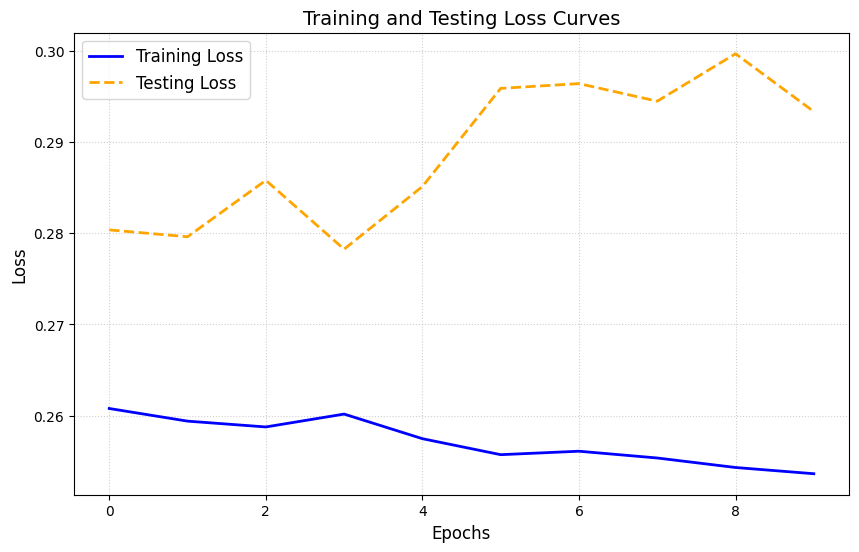

In [122]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_loss, test_loss):
    plt.figure(figsize=(10, 6))
    
    # Plot train and test losses
    plt.plot(train_loss, label='Training Loss', color='blue', lw=2)
    plt.plot(test_loss, label='Testing Loss', color='orange', lw=2, linestyle='--')
    
    # Styling options
    plt.title('Training and Testing Loss Curves', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Render the plot
    plt.show()

# Call the function
plot_loss_curves(train_losses, test_losses)


In [119]:
print(train_loss)

3148.824496566085
